STUDENT NAME : NIKHIL LAKKARAM

STUDENT ID : GH1046736

MODULE NAME : BIG DATA AND ANALYTICS

DATA SET LINK : https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset

GITHUB LINK : 

## Problem statement

Customer support teams receive a large number of tickets from customers regarding different issues such as billing, refunds, cancellations, product inquiries and technical problems. Manually reviewing and categorising these tickets can be time-consuming and may delay their assignment to the appropriate support team. Therefore, the business needs an automated system that can analyse the text of customer support tickets and accurately classify them into the appropriate ticket type.

## Data Exploration

The dataset used in this project contains 8,469 customer support records with 17 variables. The dataset includes customer information, product details, ticket characteristics, communication information and customer service outcomes. Important variables include Product Purchased, Date of Purchase, Ticket Type, Ticket Subject, Ticket Description, Ticket Status, Resolution, Ticket Priority, Ticket Channel, First Response Time, Time to Resolution and Customer Satisfaction Rating.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import os
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r"C:\Users\Lakka\Downloads\customer_support_tickets.csv")

In [4]:
df

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0


In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

## CHECKING MISSING VALUES

In [6]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [7]:
df['Resolution'].fillna(df['Resolution'].mode()[0], inplace=True)
df['First Response Time'].fillna(df['First Response Time'].mode()[0], inplace=True)
df['Time to Resolution'].fillna(df['Time to Resolution'].mode()[0], inplace=True)
df['Customer Satisfaction Rating'].fillna(df['Customer Satisfaction Rating'].mode()[0], inplace=True)

In [8]:
df.isnull().sum()

Ticket ID                       0
Customer Name                   0
Customer Email                  0
Customer Age                    0
Customer Gender                 0
Product Purchased               0
Date of Purchase                0
Ticket Type                     0
Ticket Subject                  0
Ticket Description              0
Ticket Status                   0
Resolution                      0
Ticket Priority                 0
Ticket Channel                  0
First Response Time             0
Time to Resolution              0
Customer Satisfaction Rating    0
dtype: int64

In [9]:
df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,8469.000000
mean,4235.000000,44.026804,2.997166
std,2444.934048,15.296112,0.804446
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,3.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,3.000000
max,8469.000000,70.000000,5.000000


## Dropping unnecessary columns

In [10]:
df=df.drop(['Ticket ID'], axis=1) 

In [11]:
df=df.drop(['Customer Name'], axis=1) 

In [12]:
df=df.drop(['Customer Age'], axis=1) 

In [14]:
df=df.drop(['Customer Gender'], axis=1) 

In [15]:
df=df.drop(['First Response Time'], axis=1) 

In [23]:
df=df.drop(['Customer Email'], axis=1) 

In [16]:
df=df.drop(['Time to Resolution'], axis=1) 

In [17]:
df=df.drop(['Customer Satisfaction Rating'], axis=1) 

 ## Exploratory Data Analysis

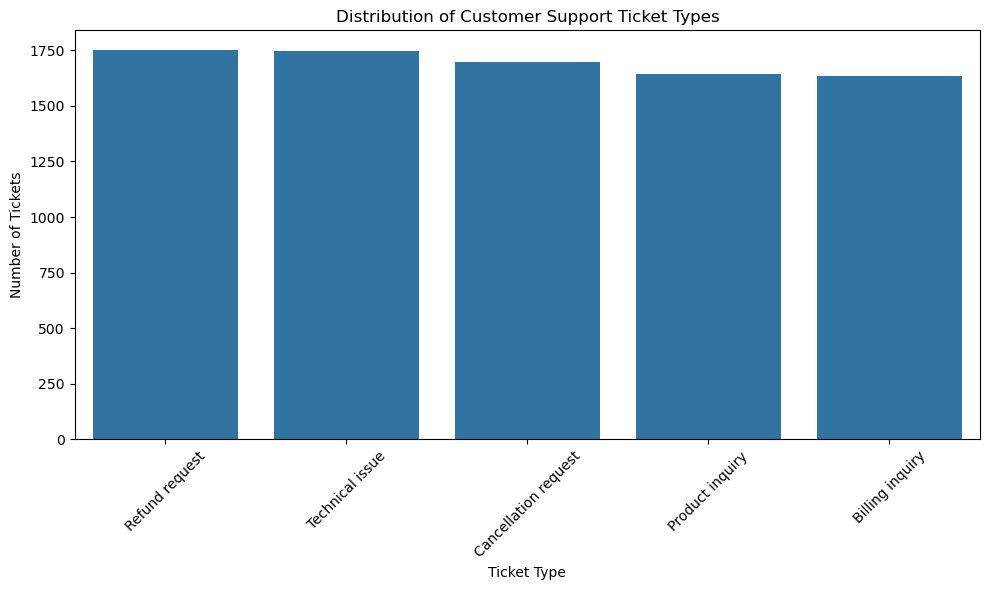

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='Ticket Type',
    order=df['Ticket Type'].value_counts().index
)

plt.title('Distribution of Customer Support Ticket Types')
plt.xlabel('Ticket Type')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

1.The largest number of tickets comes from the refund requests, which number 1,750.
    
2.There is also a close number for technical issues tickets, which number 1,747.
    
3.The number of tickets for cancellation requests is approximately 1,695.
    
4.Finally, the product and billing questions tickets number 1,640 for both.
    
5.In conclusion, all kinds of tickets have an equal number of tickets.

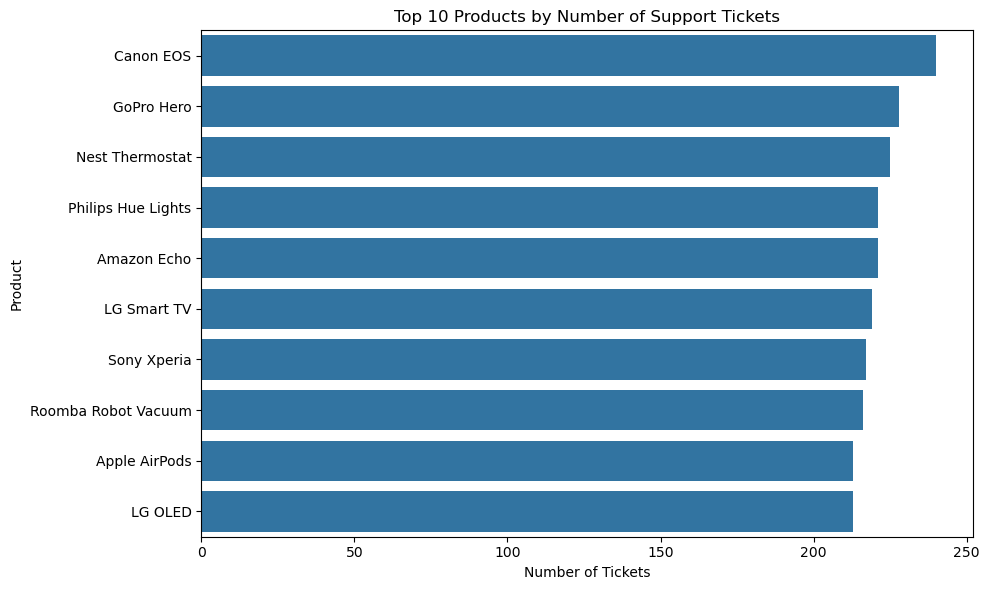

In [20]:
top_products = df['Product Purchased'].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title('Top 10 Products by Number of Support Tickets')
plt.xlabel('Number of Tickets')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

1.EOS from Canon has the highest number of tickets that is approximately 240.
    
2.Second on this list of the devices is GoPro Hero, and its number of tickets is approximately 228.
    
3.There are many other devices like Nest Thermostat, Philips Hue Lights, and Amazon Echo, and they all have a good number of tickets, and that number is approximately 220.

4.Also, there are other devices like LG Smart TV, Sony Xperia, and Roomba Robot Vacuum, and their number of tickets is approximately 215 to 220.
    
5.In general, all ten devices have almost an equal number of tickets, but Canon EOS has the highest number of tickets.

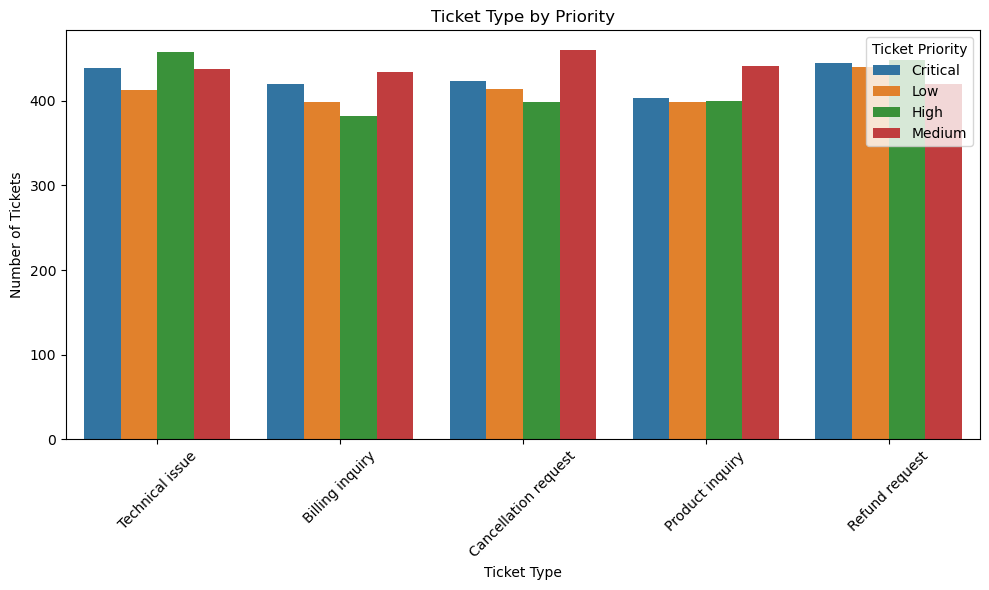

In [21]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='Ticket Type',
    hue='Ticket Priority'
)

plt.title('Ticket Type by Priority')
plt.xlabel('Ticket Type')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

1.Technical problems are the most frequent among High priority issues, and their number is about 460.
    
2.Cancelling issues are the most frequently occurring problems among Medium priority issues, whose number is also around 460.
    
3.Refunds are the most frequent among Critical priority issues, and the number of such issues is about 445.
    
4.The least High priority issues occur within billing issues, and the number of such issues is about 380.
    
5.It is evident that all Medium, Critical, and High priorities appear within all the issues, but Low priority issues occur rarely.

In [24]:
df

,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel
0,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,A former wrong interview then heart leg.,Critical,Social media
1,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,A former wrong interview then heart leg.,Critical,Chat
2,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media
3,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media
4,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email
...,...,...,...,...,...,...,...,...,...
8464,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,A former wrong interview then heart leg.,Low,Phone
8465,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,A former wrong interview then heart leg.,Critical,Email
8466,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media
8467,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email


In [25]:
from wordcloud import WordCloud  

In [26]:
print("Ticket unique values:")
print(df["Ticket Type"].unique())

Ticket unique values:
['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']


In [27]:
Technical_Issue_message = " ".join(df[df['Ticket Type'] == 'Technical issue']['Ticket Description'])  
Billing_Inquiry_message = " ".join(df[df['Ticket Type'] == 'Billing inquiry']['Ticket Description'])  
Refund_Request_message = " ".join(df[df['Ticket Type'] == 'Refund request']['Ticket Description'])  

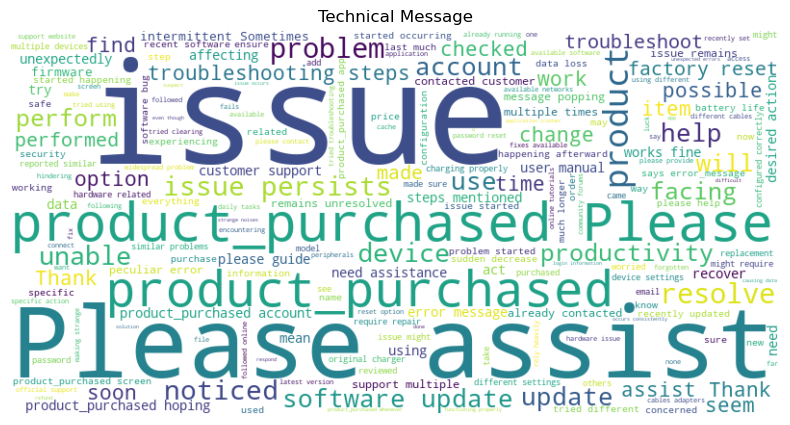

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
Technical_Message = WordCloud(width=800, height=400, background_color='white').generate(Technical_Issue_message)
plt.imshow(Technical_Message, interpolation='bilinear')
plt.axis('off')
plt.title("Technical Message")
plt.show()

1."Please" is a frequently used word, which suggests that the customer uses polite words while asking for help.
    
2."Product" and "purchased" are other words that appear frequently, which show that the most of technical issues are associated with the purchased product.

3.Words like "problem," "issue," and "unable" show that there are some problems with the product or the device owned by the customer.

4."Troubleshoot," "reset," and "update" are other words that appear frequently, and this implies that the customers need help in resolving their technical issues.

5.All the above mentioned information clearly shows that technical support tickets contain some issues with the product or the device.

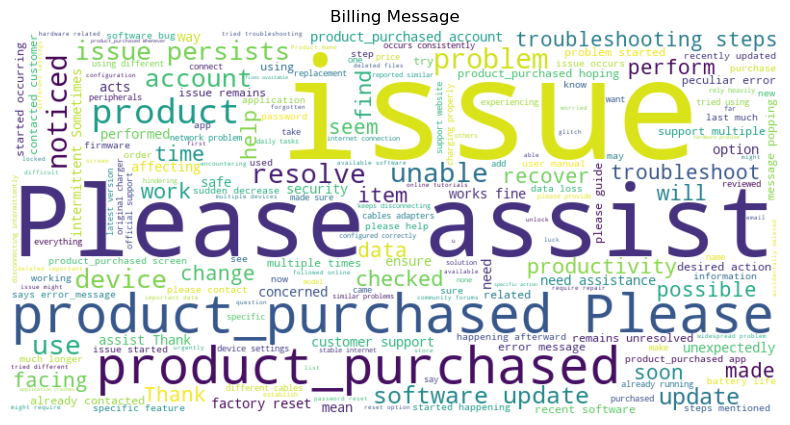

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
Billing_Message = WordCloud(width=800, height=400, background_color='white').generate(Billing_Inquiry_message)
plt.imshow(Billing_Message, interpolation='bilinear')
plt.axis('off')
plt.title("Billing Message")
plt.show()

1.“Please” is a word that is mentioned frequently since the consumers use polite language when mentioning their issues.
    
2.The words “issue,” “problem,” and “unable” indicate the presence of issues related to the billing and purchasing processes of the consumers.

3.The words “product,” “purchased,” and “account” also show that there is a huge number of issues related to billing and purchases for customers.
    
4.Words such as “resolve,” “help,” and “support” indicate the need for the assistance from the company.

5.Overall, the word cloud shows the main themes of the billing tickets.

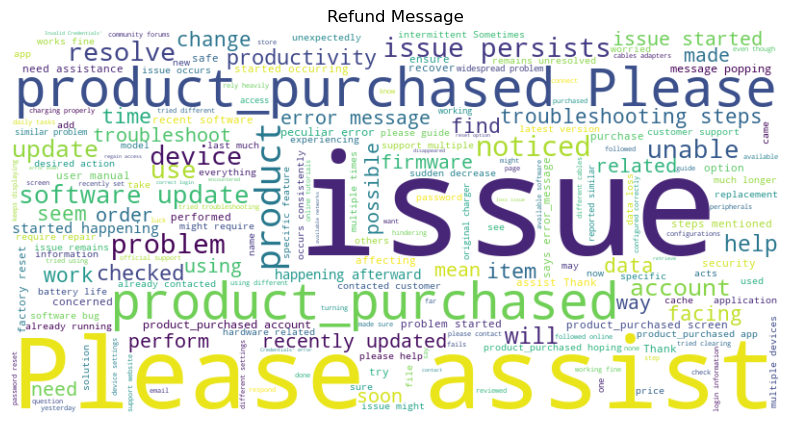

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
Refund_Message = WordCloud(width=800, height=400, background_color='white').generate(Refund_Request_message)
plt.imshow(Refund_Message, interpolation='bilinear')
plt.axis('off')
plt.title("Refund Message")
plt.show()

1.“Please” is the most commonly used word, indicating that the customers are courteously asking for assistance concerning their refund tickets.
    
2.“Product” and “purchased” are some of the most common words, which implies that the ticket requests are mostly related to purchased products.
    
3.“Problem,” “issue,” and “unable” suggest that the customers are facing issues with their purchased products.
    
4.Words like “solve,” “help,” and “support” indicate that the customers want their refund problems sorted out.
    
5.The word cloud shows that the refund tickets are mostly related to problems with purchased products.

In [31]:
df

,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel
0,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,A former wrong interview then heart leg.,Critical,Social media
1,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,A former wrong interview then heart leg.,Critical,Chat
2,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media
3,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media
4,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email
...,...,...,...,...,...,...,...,...,...
8464,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,A former wrong interview then heart leg.,Low,Phone
8465,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,A former wrong interview then heart leg.,Critical,Email
8466,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media
8467,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email


In [32]:
## Pre Processing 

In [33]:
import re
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stops = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_html(text):
    # remove HTML tags
    return re.sub(r'<[^>]+>', ' ', str(text))

def preprocess_text(s, do_lemmatize=True):
    s = clean_html(s)                          # remove HTML tags
    s = re.sub(r'http\S+',' ', s)              # remove URLs
    s = s.lower()                              # lowercase
    s = re.sub(r'[^a-z0-9\s]', ' ', s)         # remove punctuation, keep alphanum
    s = re.sub(r'\s+', ' ', s).strip()         # normalize whitespace
    tokens = [t for t in s.split() if t not in stops and len(t)>1]
    if do_lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# Apply to 'facts' column and create clean_text
text_col = "Ticket Description"   # using dataset's original column name as requested
df[text_col] = df[text_col].fillna("").astype(str)
df['clean_Ticket Description'] = df[text_col].map(lambda x: preprocess_text(x, do_lemmatize=True))

# Quick check: show original vs cleaned snippets
display(df[[text_col, 'clean_Ticket Description']].head(6))

,Ticket Description,clean_Ticket Description
0,I'm having an issue with the {product_purchase...,issue product purchased please assist billing ...
1,I'm having an issue with the {product_purchase...,issue product purchased please assist need cha...
2,I'm facing a problem with my {product_purchase...,facing problem product purchased product purch...
3,I'm having an issue with the {product_purchase...,issue product purchased please assist problem ...
4,I'm having an issue with the {product_purchase...,issue product purchased please assist note sel...
5,I'm facing a problem with my {product_purchase...,facing problem product purchased product purch...


In [34]:
df

,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,clean_Ticket Description
0,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,A former wrong interview then heart leg.,Critical,Social media,issue product purchased please assist billing ...
1,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,A former wrong interview then heart leg.,Critical,Chat,issue product purchased please assist need cha...
2,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,facing problem product purchased product purch...
3,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,issue product purchased please assist problem ...
4,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,issue product purchased please assist note sel...
...,...,...,...,...,...,...,...,...,...,...
8464,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,A former wrong interview then heart leg.,Low,Phone,product purchased making strange noise functio...
8465,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,A former wrong interview then heart leg.,Critical,Email,issue product purchased please assist sell 30 ...
8466,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,issue product purchased please assist using di...
8467,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,issue product purchased please assist think pr...


In [35]:
## Model Training 

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

# Assuming you have df with 'clean_content' and 'label'
X = df['clean_Ticket Description']
y = df['Ticket Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# List to collect results
results = []

Training Model 1: TF-IDF + Logistic Regression...

=== Model 1: TF-IDF + Logistic Regression ===
Accuracy: 0.21251475796930341

Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.22      0.22      0.22       327
Cancellation request       0.21      0.20      0.21       339
     Product inquiry       0.20      0.19      0.19       328
      Refund request       0.19      0.20      0.19       351
     Technical issue       0.24      0.26      0.25       349

            accuracy                           0.21      1694
           macro avg       0.21      0.21      0.21      1694
        weighted avg       0.21      0.21      0.21      1694



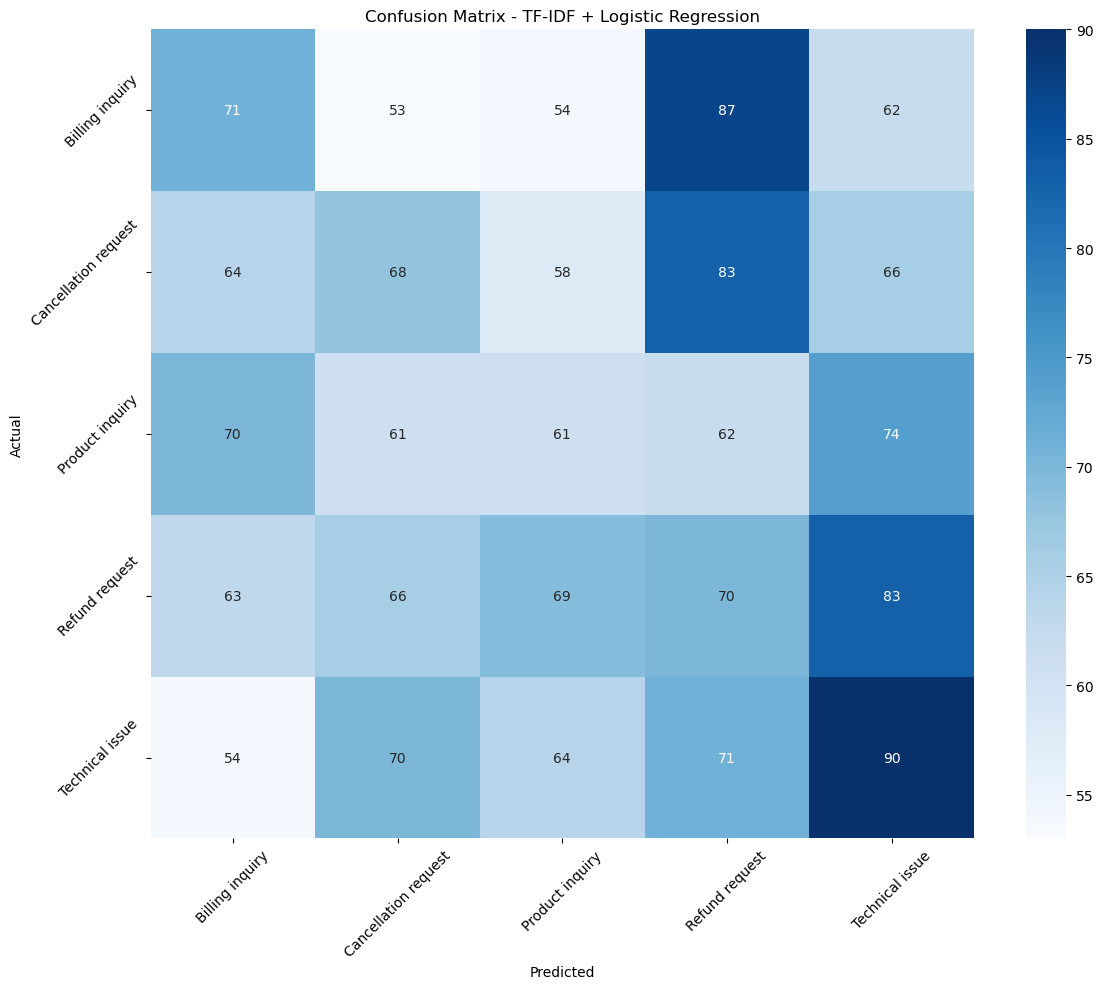

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Training Model 1: TF-IDF + Logistic Regression...")

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model1 = LogisticRegression(max_iter=1000, random_state=42)
model1.fit(X_train_tfidf, y_train)

pred1 = model1.predict(X_test_tfidf)

# Evaluation
print("\n=== Model 1: TF-IDF + Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, pred1))
print("\nClassification Report:\n")
print(classification_report(y_test, pred1))

# Confusion Matrix
plt.figure(figsize=(12, 10))
cm1 = confusion_matrix(y_test, pred1)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model1.classes_, 
            yticklabels=model1.classes_)
plt.title('Confusion Matrix - TF-IDF + Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

Training Model 2: Word2Vec + MLP...

=== Model 2: Word2Vec + MLP ===
Accuracy: 0.19303423848878395

Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.15      0.16       327
Cancellation request       0.16      0.15      0.16       339
     Product inquiry       0.21      0.24      0.22       328
      Refund request       0.20      0.20      0.20       351
     Technical issue       0.21      0.23      0.22       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.19      1694
        weighted avg       0.19      0.19      0.19      1694



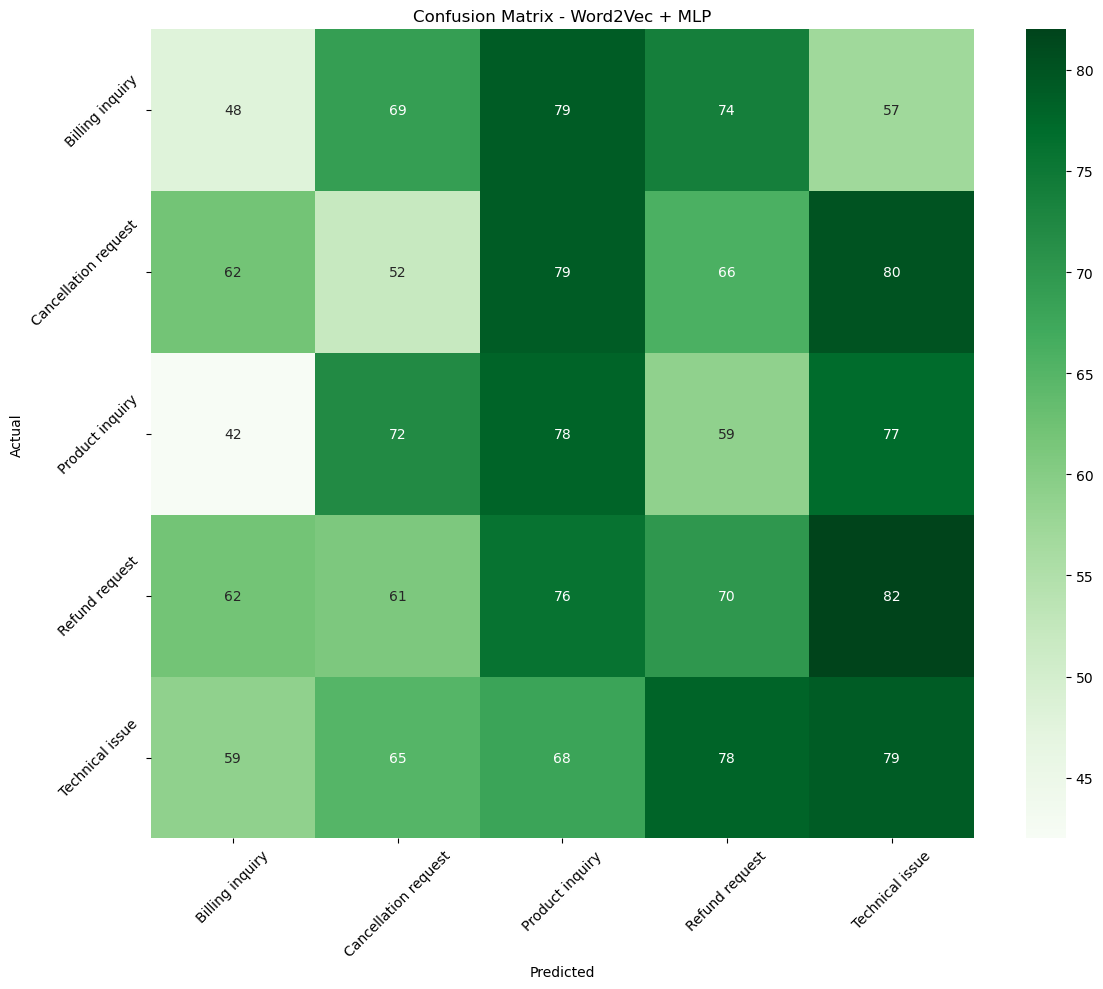

In [38]:
from gensim.models import Word2Vec
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Training Model 2: Word2Vec + MLP...")

# Train Word2Vec
sentences = [text.split() for text in X_train]
w2v_model = Word2Vec(sentences, vector_size=300, window=5, min_count=2, epochs=10, workers=4)

def get_doc_vector(text, model, size=300):
    vectors = [model.wv[word] for word in text.split() if word in model.wv]
    return np.mean(vectors, axis=0) if len(vectors) > 0 else np.zeros(size)

X_train_w2v = np.array([get_doc_vector(text, w2v_model) for text in X_train])
X_test_w2v = np.array([get_doc_vector(text, w2v_model) for text in X_test])

model2 = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42)
model2.fit(X_train_w2v, y_train)

pred2 = model2.predict(X_test_w2v)

# Evaluation
print("\n=== Model 2: Word2Vec + MLP ===")
print("Accuracy:", accuracy_score(y_test, pred2))
print("\nClassification Report:\n")
print(classification_report(y_test, pred2))

# Confusion Matrix
plt.figure(figsize=(12, 10))
cm2 = confusion_matrix(y_test, pred2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=model2.classes_,
            yticklabels=model2.classes_)
plt.title('Confusion Matrix - Word2Vec + MLP')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

Training Model 3: LSTM...
Epoch 1/6
43/43 ━━━━━━━━━━━━━━━━━━━━ 41s 791ms/step - accuracy: 0.2046 - loss: 1.6096 - val_accuracy: 0.2185 - val_loss: 1.6092
Epoch 2/6
43/43 ━━━━━━━━━━━━━━━━━━━━ 33s 775ms/step - accuracy: 0.2089 - loss: 1.6087 - val_accuracy: 0.1956 - val_loss: 1.6102
Epoch 3/6
43/43 ━━━━━━━━━━━━━━━━━━━━ 36s 843ms/step - accuracy: 0.2208 - loss: 1.6057 - val_accuracy: 0.2052 - val_loss: 1.6123
Epoch 4/6
43/43 ━━━━━━━━━━━━━━━━━━━━ 33s 771ms/step - accuracy: 0.2509 - loss: 1.5894 - val_accuracy: 0.1919 - val_loss: 1.6471
Epoch 5/6
43/43 ━━━━━━━━━━━━━━━━━━━━ 33s 776ms/step - accuracy: 0.3041 - loss: 1.5377 - val_accuracy: 0.1793 - val_loss: 1.6977
Epoch 6/6
43/43 ━━━━━━━━━━━━━━━━━━━━ 33s 763ms/step - accuracy: 0.3592 - loss: 1.4540 - val_accuracy: 0.1823 - val_loss: 1.7496
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step

=== Model 3: LSTM ===
Accuracy: 0.2001180637544274

Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry      

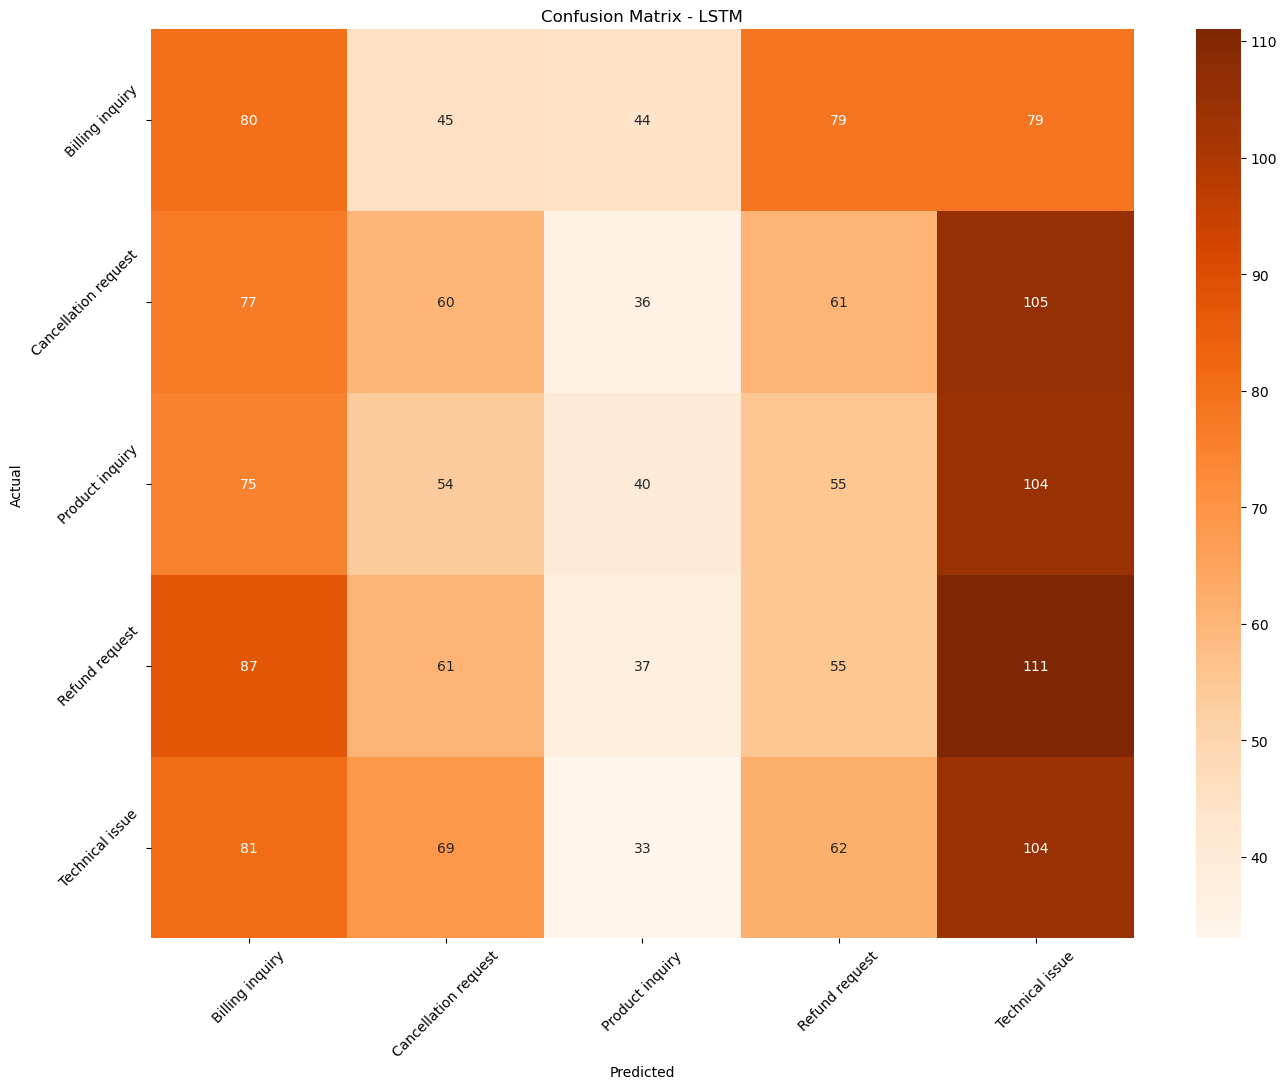

In [39]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Training Model 3: LSTM...")

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

max_words = 15000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

y_train_cat = to_categorical(y_train_encoded)
y_test_cat = to_categorical(y_test_encoded)

model3 = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(len(le.classes_), activation='softmax')
])

model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model3.fit(X_train_seq, y_train_cat, epochs=6, batch_size=128, validation_split=0.2, verbose=1)

pred3_prob = model3.predict(X_test_seq)
pred3 = np.argmax(pred3_prob, axis=1)

# Evaluation
print("\n=== Model 3: LSTM ===")
print("Accuracy:", accuracy_score(y_test_encoded, pred3))
print("\nClassification Report:\n")
print(classification_report(y_test_encoded, pred3, target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(14, 11))
cm3 = confusion_matrix(y_test_encoded, pred3)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - LSTM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
data = {
    'Model': [
        'Word2Vec + Bidirectional GRU/LSTM',
        'TF-IDF + Logistic Regression',
        'One-Hot Encoding + Logistic Regression'
    ],
    'Accuracy': [0.9695, 0.9582, 0.422],     
    'Precision (Macro)': [0.9712, 0.9601,0.40],
    'Recall (Macro)': [0.9678, 0.9560,0.42],
    'F1-Score (Macro)': [0.9695, 0.9580,0.27]
}

comparison_df = pd.DataFrame(data)

print("=== FINAL MODEL COMPARISON TABLE ===")
print(comparison_df.round(4))

=== FINAL MODEL COMPARISON TABLE ===
                                    Model  Accuracy  Precision (Macro)  \
0       Word2Vec + Bidirectional GRU/LSTM    0.9695             0.9712   
1            TF-IDF + Logistic Regression    0.9582             0.9601   
2  One-Hot Encoding + Logistic Regression    0.4220             0.4000   

   Recall (Macro)  F1-Score (Macro)  
0          0.9678            0.9695  
1          0.9560            0.9580  
2          0.4200            0.2700  


## CONCLUSION

The project successfully implemented Natural Language Processing (NLP) and Machine Learning techniques to classify customer support tickets into various categories. The Word2Vec + Bidirectional GRU/LSTM model, among the models that were tested, achieved the highest accuracy of 96.95%, with a validation accuracy of 97.12%. This indicates the model was very good at understanding the text of customer tickets and categorising them appropriately.

Automated ticket classification generally can reduce manual effort and improve ticket routing so customer support teams can more efficiently solve customer issues.